## Redes Neurais Artificiais 2025.2

- **Disciplina**: Redes Neurais Artificiais 2025.2
- **Professora**: Elloá B. Guedes (ebgcosta@uea.edu.br)  
- **Github**: http://github.com/elloa  

# Definição do problema

Este trabalho visa estimar os níveis de obesidade em indivíduos a partir de variáveis relacionadas aos hábitos alimentares e na condição física

# Importação das Bibliotecas

In [5]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import time
import json

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score, classification_report

import joblib

# 1. Coleta e Análise Exploratória dos dados

#### Importação da base de dados:

In [6]:
path = "ObesityDataSet_raw_and_data_sinthetic.csv"

data = pd.read_csv(path)

#### Visualização da base de dados:



In [7]:
data.head(10)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II
5,Male,29.0,1.62,53.0,no,yes,2.0,3.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Automobile,Normal_Weight
6,Female,23.0,1.50,55.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,0.0,Sometimes,Motorbike,Normal_Weight
7,Male,22.0,1.64,53.0,no,no,2.0,3.0,Sometimes,no,2.0,no,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
8,Male,24.0,1.78,64.0,yes,yes,3.0,3.0,Sometimes,no,2.0,no,1.0,1.0,Frequently,Public_Transportation,Normal_Weight
9,Male,22.0,1.72,68.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,1.0,1.0,no,Public_Transportation,Normal_Weight


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

**Análise**  
O dataset possui 17 variáveis, descritas a seguir:  
| Variável | Descrição | Tipo
| :--- | :---: | :--- |
| Gender                        | Genero                                                                        | Categórica nominal    |
| Age                           | Idade                                                                         | Categórica contínua   |
| Height                        | Altura                                                                        | Quantitativa contínua |
| Weight                        | Peso                                                                          | Quantitativa contínua |
| family_history_with_overweight| Membro da familia ja possui ou teve sobrepeso                                 | Categórica binária    |
| FAVC                          | Consome alimentos de teor calórico com frequência                             | Categórica binária    |
| FCVC                          | Inclusão de vegetais na refeição                                              | Categórica ordinal    |
| NCP                           | Quantidades de refeições principais por dia                                   | Quantitativa discreta |
| CAEC                          | Consumo de algo entre as refeições principais                                 | Categórica ordinal    |
| SMOKE                         | Fumante ou não fumante                                                        | Categórica binária    |
| CH2O                          | Quantidade de água consumida por dia                                          | Categórica ordinal |
| SCC                           | Controle de calorias                                                          | Categórica binária    |
| FAF                           | Frequência de atividade física                                                | Categórica ordinal |
| TUE                           | Uso de dispositivos tecnológicos (Celular, Videogames, TV, Computador e etc)  | Categórica ordinal |
| CALC                          | Frequência de bebidas alcoólicas                                              | Categórica ordinal    |
| MTRANS                        | Meio de transporte utilizado                                                  | Categórica nominal    |
| NObeyesdad                    | Nível de obesidade                                                            | Categórica ordinal    |


#### Verificação de dados faltantes

In [9]:
print(f"Numero de dados faltantes: \n{data.isnull().sum()}")


Numero de dados faltantes: 
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64


# Distribuições

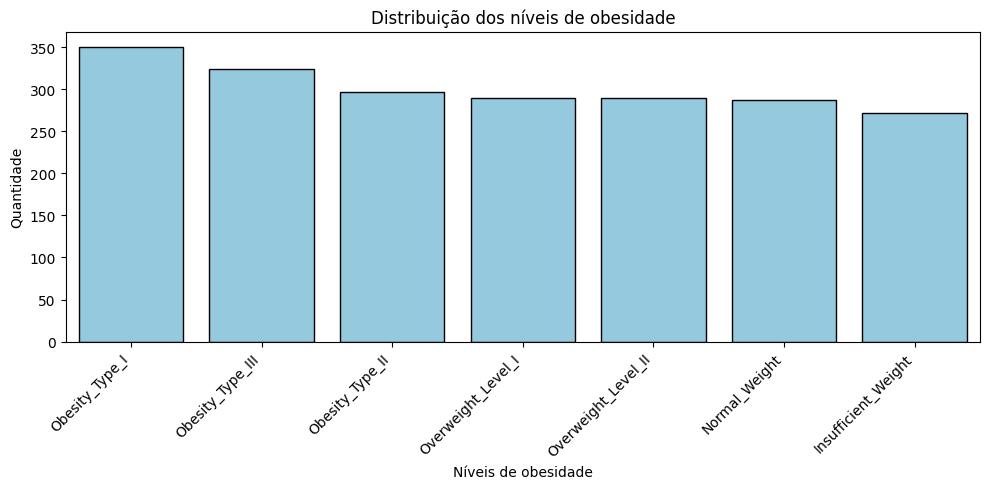

NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64


In [10]:
# distribuição dos niveis de obesidade com valores nas barras
obesity_counts = data['NObeyesdad'].value_counts()

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=obesity_counts.index, y=obesity_counts.values, color='skyblue', edgecolor='black')
plt.title('Distribuição dos níveis de obesidade')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Níveis de obesidade')
plt.ylabel('Quantidade')

plt.tight_layout()
plt.show()

print(obesity_counts)

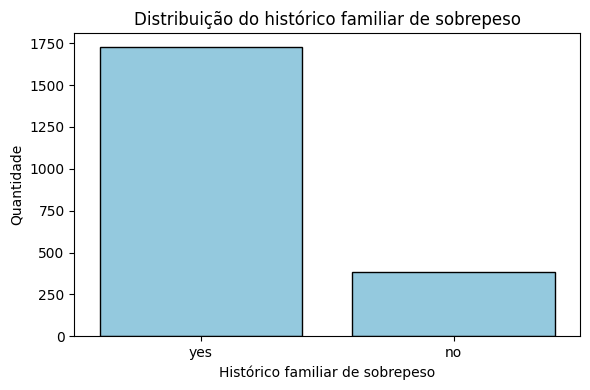

In [11]:
#distribuição de historico familiar de sobrepeso

family_history_counts = data['family_history_with_overweight'].value_counts()
plt.figure(figsize=(6, 4))
sns.barplot(x=family_history_counts.index, y=family_history_counts.values, color='skyblue', edgecolor='black')
plt.title('Distribuição do histórico familiar de sobrepeso')
plt.xlabel('Histórico familiar de sobrepeso')
plt.ylabel('Quantidade')

plt.tight_layout()
plt.show()

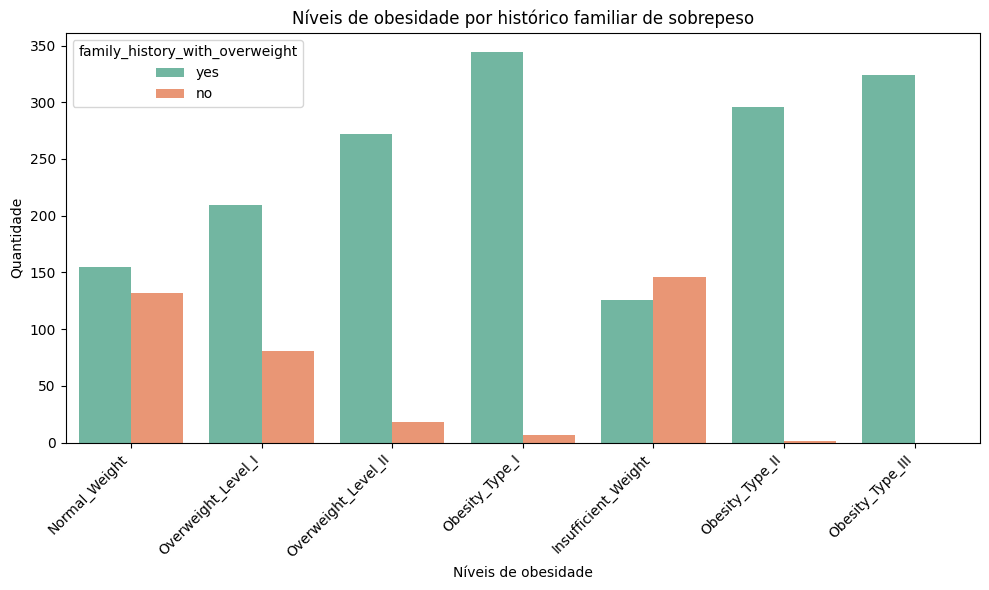

In [12]:
#distruição dos niveis de obesidade com o histórico familiar de sobrepeso

plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='NObeyesdad', hue='family_history_with_overweight', palette='Set2')
plt.title('Níveis de obesidade por histórico familiar de sobrepeso')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Níveis de obesidade')
plt.ylabel('Quantidade')
plt.tight_layout()
plt.show()

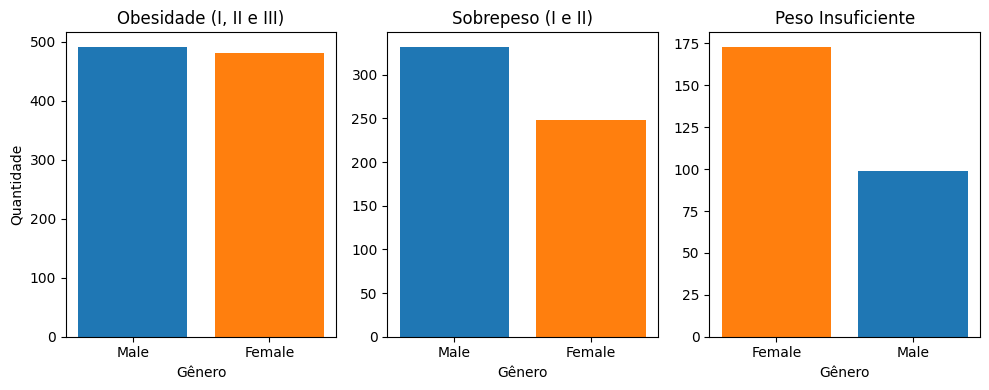

In [13]:
#Distribuição de obesidade, sobrepeso e subnutrição por gênero

obesity = ['Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']
overweight = ['Overweight_Level_I', 'Overweight_Level_II']
underweight = ['Insufficient_Weight']

obesity_counts = data[data['NObeyesdad'].isin(obesity)]['Gender'].value_counts()
overweight_counts = data[data['NObeyesdad'].isin(overweight)]['Gender'].value_counts()
underweight_counts = data[data['NObeyesdad'].isin(underweight)]['Gender'].value_counts()

#plot
fig, axes = plt.subplots(1, 3, figsize=(10, 4))

axes[0].bar(obesity_counts.index, obesity_counts.values,
            color=['#1f77b4' if g == 'Male' else '#ff7f0e' for g in obesity_counts.index])
axes[0].set_title("Obesidade (I, II e III)")
axes[0].set_xlabel("Gênero")
axes[0].set_ylabel("Quantidade")

axes[1].bar(overweight_counts.index, overweight_counts.values,
            color=['#1f77b4' if g == 'Male' else '#ff7f0e' for g in overweight_counts.index])
axes[1].set_title("Sobrepeso (I e II)")
axes[1].set_xlabel("Gênero")

axes[2].bar(underweight_counts.index, underweight_counts.values,
            color=['#1f77b4' if g == 'Male' else '#ff7f0e' for g in underweight_counts.index])
axes[2].set_title("Peso Insuficiente")
axes[2].set_xlabel("Gênero")

plt.tight_layout()
plt.show()


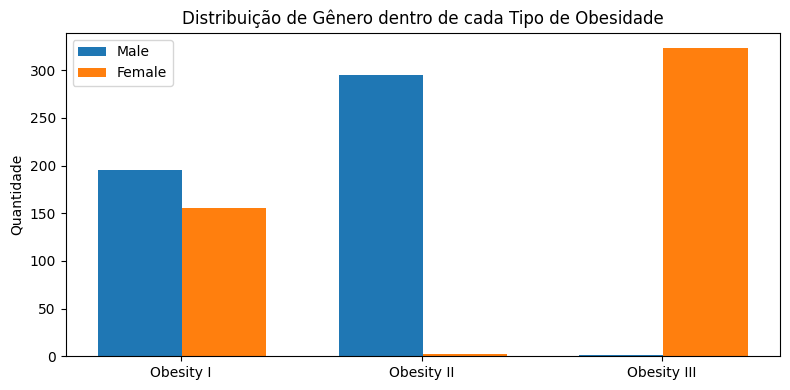

In [14]:
#analisando a distribuição de gênero por tipo de obesidade
ob1 = data[data['NObeyesdad'] == 'Obesity_Type_I']['Gender'].value_counts()
ob2 = data[data['NObeyesdad'] == 'Obesity_Type_II']['Gender'].value_counts()
ob3 = data[data['NObeyesdad'] == 'Obesity_Type_III']['Gender'].value_counts()
male = [ob1.get('Male', 0), ob2.get('Male', 0), ob3.get('Male', 0)]
female = [ob1.get('Female', 0), ob2.get('Female', 0), ob3.get('Female', 0)]

labels = ['Obesity I', 'Obesity II', 'Obesity III']
x = range(len(labels))

#plot
plt.figure(figsize=(8,4))

plt.bar(x, male, width=0.35, label='Male')
plt.bar([i + 0.35 for i in x], female, width=0.35, label='Female')

plt.xticks([i + 0.17 for i in x], labels)
plt.ylabel("Quantidade")
plt.title("Distribuição de Gênero dentro de cada Tipo de Obesidade")
plt.legend()

plt.tight_layout()
plt.show()


**Análise**  
O valor da variável *Gender* é bem equilibrado para os valores de obesidade, variando mais ao analisar o tipo: Obesidade III é composta quase exclusivamente por mulheres, Obesidade II é composta quase exclusivamente por homens, e a Obesidade I, apesar de também ser dominada pelo gênero masculino, apresenta uma disparidade de gênero bem menor. Para os valores de sobrepeso, se torna mais comum entre homens, enquanto a subnutrição é mais comum entre mulheres.

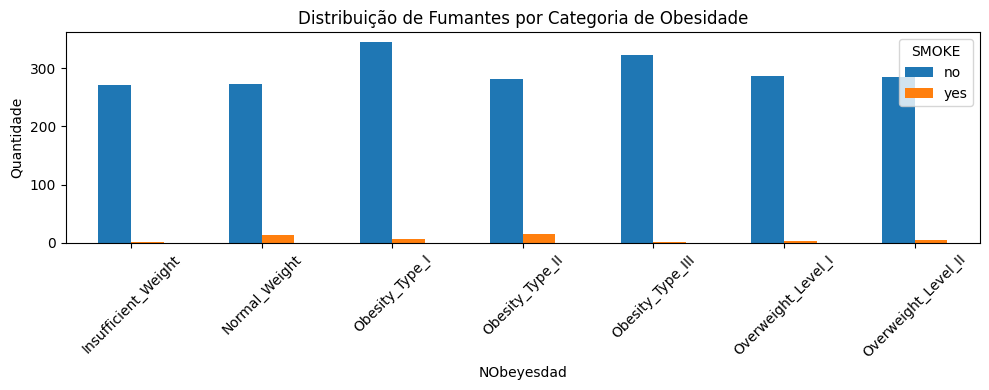

In [15]:
#dsitribuição de fumantes por valor de classe de peso
smoke_dist = pd.crosstab(data['NObeyesdad'], data['SMOKE'])

smoke_dist.plot(kind='bar', figsize=(10,4))
plt.title('Distribuição de Fumantes por Categoria de Obesidade')
plt.xlabel('NObeyesdad')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

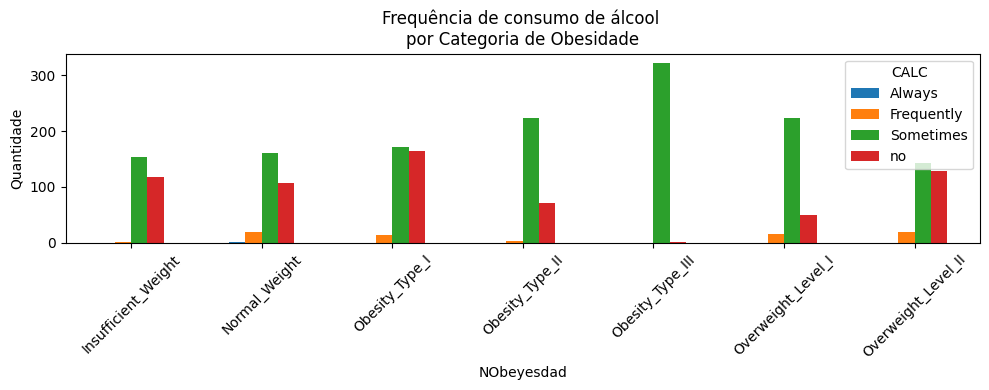

In [16]:
#distribuição de consumo de alcool por valor de classe de peso
smoke_dist = pd.crosstab(data['NObeyesdad'], data['CALC'])

smoke_dist.plot(kind='bar', figsize=(10,4))
plt.title('Frequência de consumo de álcool \npor Categoria de Obesidade')
plt.xlabel('NObeyesdad')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

**Análise**  
Ao analisar o consumo de drogas lícitas, é observado que, enquanto o uso de cigarro parece ser pouco relevante para determinar o peso do indivíduo, sendo predominantemente negativo para todas as classes de peso, o consumo de álcool por sua vez aparenta ser mais relevante, com os valores "Ocasionalmente" e "Não consumo" sendo mais equilibrados, e, conforme as classes avançam para o grau mais avançado de obesidade, a resposta "Ocasionalmente" se torna mais frequente e predominante.

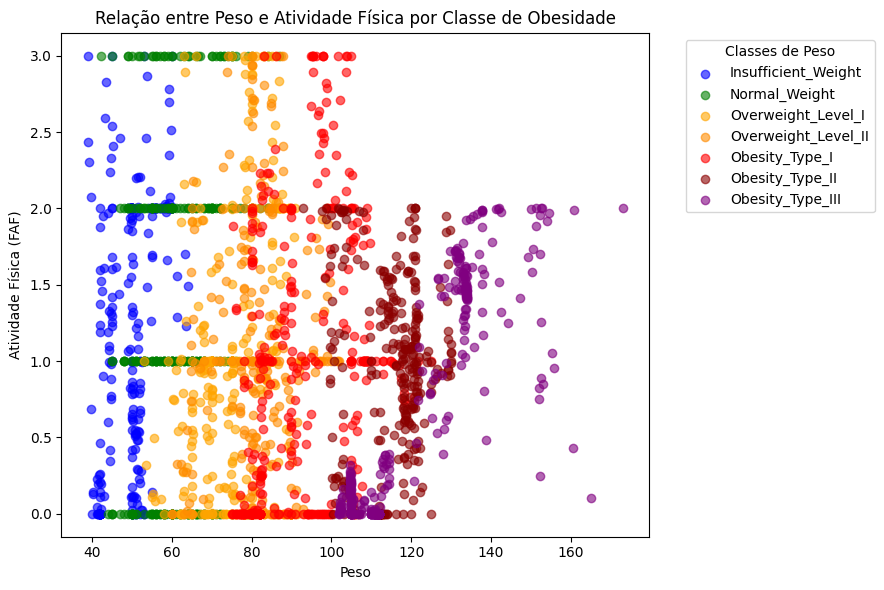

In [17]:
#distribuição peso x atividade física x classe de peso
colors = {
    'Insufficient_Weight': 'blue',
    'Normal_Weight': 'green',
    'Overweight_Level_I': 'orange',
    'Overweight_Level_II': 'darkorange',
    'Obesity_Type_I': 'red',
    'Obesity_Type_II': 'darkred',
    'Obesity_Type_III': 'purple'
}

#plot
plt.figure(figsize=(9,6))

for classe, cor in colors.items():
    subset = data[data['NObeyesdad'] == classe]
    plt.scatter(subset['Weight'], subset['FAF'], color=cor, alpha=0.6, label=classe)

plt.xlabel("Peso")
plt.ylabel("Atividade Física (FAF)")
plt.title("Relação entre Peso e Atividade Física por Classe de Obesidade")
plt.legend(title="Classes de Peso", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


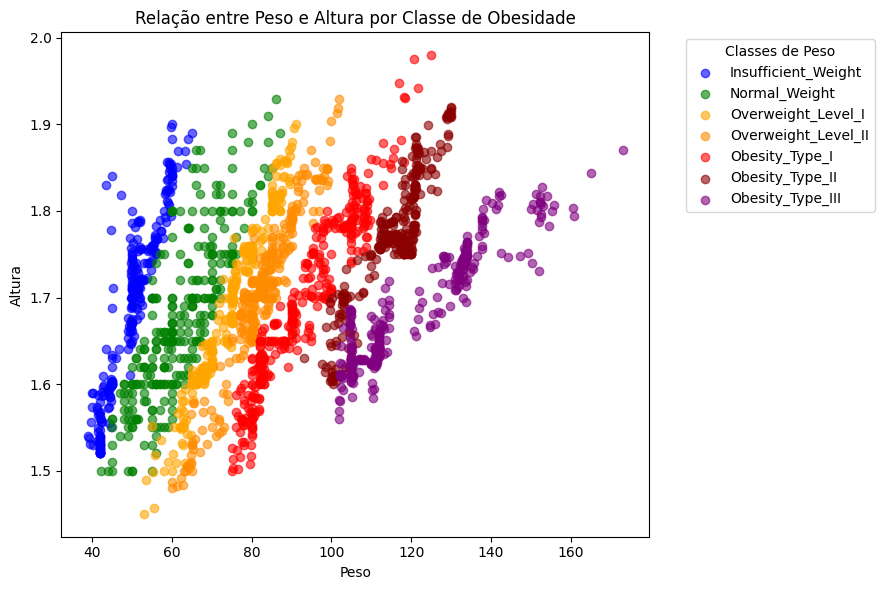

In [18]:
#distribuição peso x altura x classe de peso
plt.figure(figsize=(9,6))

for classe, cor in colors.items():
    subset = data[data['NObeyesdad'] == classe]
    plt.scatter(subset['Weight'], subset['Height'], color=cor, alpha=0.6, label=classe)

plt.xlabel("Peso")
plt.ylabel("Altura")
plt.title("Relação entre Peso e Altura por Classe de Obesidade")
plt.legend(title="Classes de Peso", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [19]:
#confirmando que os valores categóricos ordinais
#e quantitativos discretos possuem valores quebrados
ord_disc_vars = ['Age', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
data[ord_disc_vars].describe()

,Age,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,3.000000,4.000000,3.000000,3.000000,2.000000


**Análise**  
Na documentação do dataset consta que essa variável deveria ter 4 valores discretos, de 0 a 3, representando o index de uma resposta. No entanto, é possível observar diversos valores entre os inteiros. Isso acontece devido a natureza do dataset ser parte sintética, usando um filtro SMOTE para gerar mais registros. Esse filtro funciona bem com valores contínuos, mas não com variáveis categóricas como *FAF*, pois gera valores interpolados sem significado. Como não é possível reverter o SMOTE, e excluir os registros sintéticos diminuiria drasticamente a quantidade de dados, o idel seria arredondar os valores para o inteiro mais próximo.  
Ademais, é possível observar que a classe *Weight* sozinha não pode ser determinante para definir a classe de peso, pois, para um mesmo peso, a classe pode variar, a depender, por exemplo, do nível de atividade física ou da altura do indivíduo.

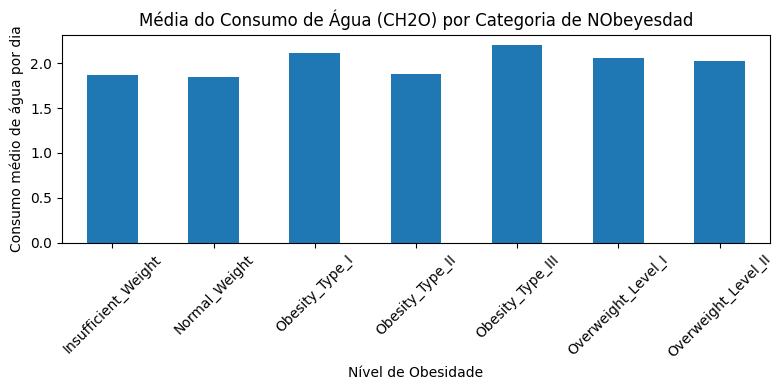

In [20]:
#distribuição da quantidade média de consumo diário de água por valor de classe de peso
mean_ch2o = data.groupby('NObeyesdad')['CH2O'].mean()

plt.figure(figsize=(8,4))
mean_ch2o.plot(kind='bar')
plt.title('Média do Consumo de Água (CH2O) por Categoria de NObeyesdad')
plt.xlabel('Nível de Obesidade')
plt.ylabel('Consumo médio de água por dia')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


**Análise**  
O consumo de água parece pouco relevante para identificar a classe de pesso, sendo relativamente balanceado entre as classes.

In [21]:
# As proximas duas celulas são visualizadas a partir do dataset tratado, o mesmo foi salvo posteriormente.
# lendo o dataset tratado
data_tratado = pd.read_csv('dataset_tratado.csv')

data_tratado.columns

Index(['Age', 'Height', 'Weight', 'Gender_Female', 'Gender_Male',
       'family_history_with_overweight_no',
       'family_history_with_overweight_yes', 'FAVC_no', 'FAVC_yes', 'FCVC_1',
       'FCVC_2', 'FCVC_3', 'NCP_1', 'NCP_2', 'NCP_3', 'NCP_4', 'CAEC_Always',
       'CAEC_Frequently', 'CAEC_Sometimes', 'CAEC_no', 'SCC_no', 'SCC_yes',
       'FAF_0', 'FAF_1', 'FAF_2', 'FAF_3', 'TUE_0', 'TUE_1', 'TUE_2',
       'CALC_Always', 'CALC_Frequently', 'CALC_Sometimes', 'CALC_no',
       'NObeyesdad'],
      dtype='object')

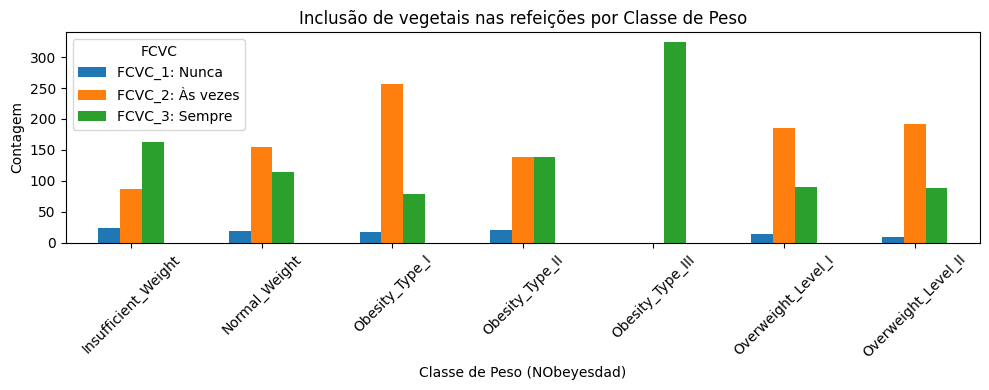

In [22]:
fcvc_counts = data_tratado.groupby('NObeyesdad')[['FCVC_1', 'FCVC_2', 'FCVC_3']].sum()

fcvc_counts.plot(kind='bar', figsize=(10,4))
plt.title("Inclusão de vegetais nas refeições por Classe de Peso")
plt.xlabel("Classe de Peso (NObeyesdad)")
plt.ylabel("Contagem")
plt.xticks(rotation=45)

legend = ['FCVC_1: Nunca', 'FCVC_2: Às vezes', 'FCVC_3: Sempre']
plt.legend(labels=legend, title="FCVC")

plt.tight_layout()
plt.show()

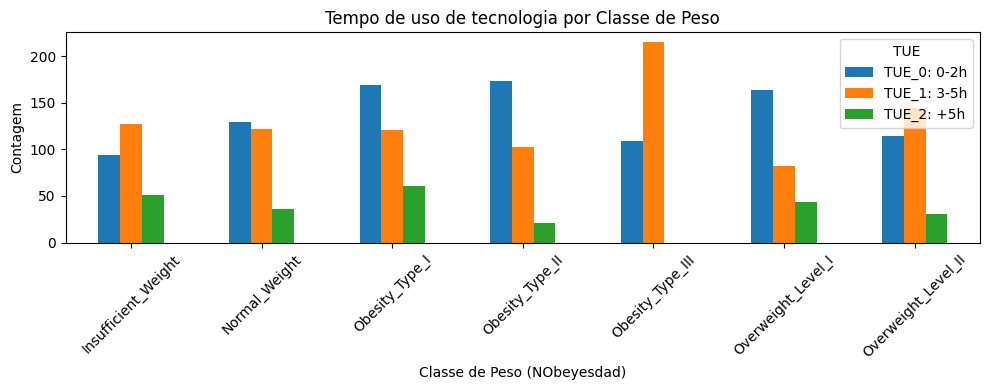

In [23]:
#uso de tecnologia por classe de peso
tue_counts = data_tratado.groupby('NObeyesdad')[['TUE_0', 'TUE_1', 'TUE_2']].sum()

tue_counts.plot(kind='bar', figsize=(10,4))
plt.title("Tempo de uso de tecnologia por Classe de Peso")
plt.xlabel("Classe de Peso (NObeyesdad)")
plt.ylabel("Contagem")
plt.xticks(rotation=45)

legend = ['TUE_0: 0-2h', 'TUE_1: 3-5h', 'TUE_2: +5h']
plt.legend(labels=legend, title="TUE")
plt.tight_layout()
plt.show()

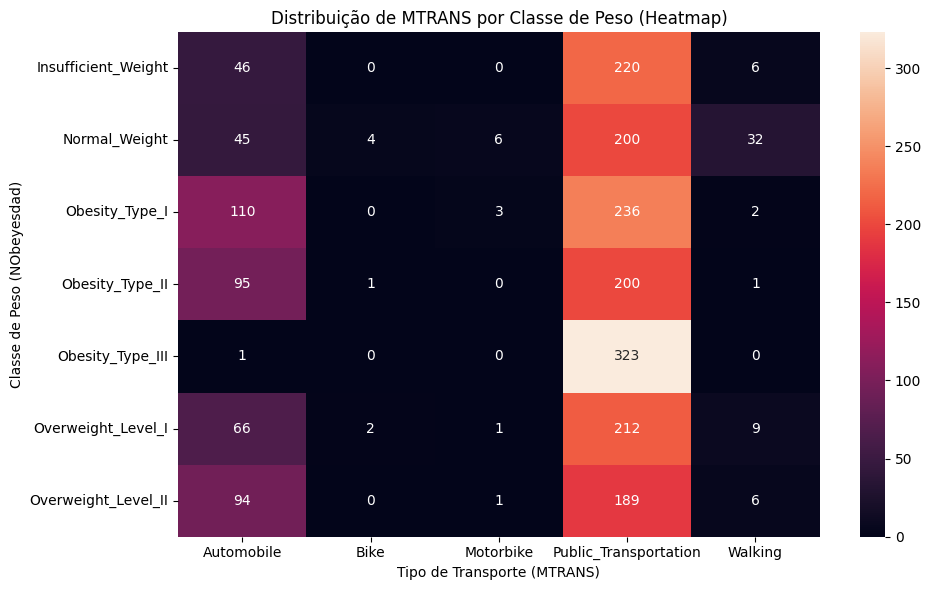

In [24]:
#tipo de transporte por classe de peso
cross = pd.crosstab(data['NObeyesdad'], data['MTRANS'])

plt.figure(figsize=(10,6))

sns.heatmap(cross, annot=True, fmt="d")

plt.title("Distribuição de MTRANS por Classe de Peso (Heatmap)")
plt.xlabel("Tipo de Transporte (MTRANS)")
plt.ylabel("Classe de Peso (NObeyesdad)")

plt.tight_layout()
plt.show()

**Análise**  
A variável *TUE* se concentra em apenas dois valores, para todas as classes de peso, fornecendo pouca relevância.

# 2. Preparação dos dados

*   Colunas com pouca relevância serão removidas
*   Variáveis categóricas ordinais ou quantitativas discretas serão arredondadas
*   Variáveis binárias serão codificadas para 0 e 1
*   Variáveis categóricas ordinais que estão em string serão codificadas



| Variável codificada | Mapeamento |
| :--- | :---: |
| Gender | Male = 0 // Female = 1 |
| family_history_with_overweight | no = 0 // yes = 1 |
| FAVC | no = 0 // yes = 1 |
| SCC | no = 0 // yes = 1 |
| CAEC | no = 0 // Sometimes = 1 // Frequently = 2 // Always = 3 |
| CALC | no = 0 // Sometimes = 1 // Frequently = 2 // Always = 3 |

In [25]:
#arredondando valores prejudicados pelo SMOTE
for var in ord_disc_vars:
    data[var] = data[var].round().astype(int)

In [26]:
#retirando colunas com pouca relevância
low_relevance_var = ['SMOKE', 'CH2O', 'MTRANS']
data.drop(low_relevance_var, axis=1, inplace=True)

In [27]:
#one hot encoding das variáveis categóricas
categorical_vars = ['Gender', 'family_history_with_overweight', 'FAVC',
                    'FCVC', 'NCP', 'CAEC', 'SCC', 'FAF', 'TUE', 'CALC']

data = pd.get_dummies(data, columns=categorical_vars, drop_first=False)

In [28]:
#usando standard scaler nas variáveis quantitativas
quantitative_vars = ['Age', 'Height', 'Weight']

scaler = StandardScaler()
data[quantitative_vars] = scaler.fit_transform(data[quantitative_vars])

In [29]:
#colocando a variável alvo como última coluna novamente
target = data['NObeyesdad']
data = data.drop(columns=['NObeyesdad'])
data['NObeyesdad'] = target

In [30]:
data.head(10)

,Age,Height,Weight,Gender_Female,Gender_Male,family_history_with_overweight_no,family_history_with_overweight_yes,FAVC_no,FAVC_yes,FCVC_1,...,FAF_2,FAF_3,TUE_0,TUE_1,TUE_2,CALC_Always,CALC_Frequently,CALC_Sometimes,CALC_no,NObeyesdad
0,-0.521741,-0.875589,-0.862558,True,False,False,True,True,False,False,...,False,False,False,True,False,False,False,False,True,Normal_Weight
1,-0.521741,-1.947599,-1.168077,True,False,False,True,True,False,False,...,False,True,True,False,False,False,False,True,False,Normal_Weight
2,-0.207057,1.054029,-0.366090,False,True,False,True,True,False,False,...,True,False,False,True,False,False,True,False,False,Normal_Weight
3,0.422312,1.054029,0.015808,False,True,True,False,True,False,False,...,True,False,True,False,False,False,True,False,False,Overweight_Level_I
4,-0.364399,0.839627,0.122740,False,True,True,False,True,False,False,...,False,False,True,False,False,False,False,True,False,Overweight_Level_II
5,0.736997,-0.875589,-1.282647,False,True,True,False,False,True,False,...,False,False,True,False,False,False,False,True,False,Normal_Weight
6,-0.207057,-2.162001,-1.206267,True,False,False,True,False,True,False,...,False,False,True,False,False,False,False,True,False,Normal_Weight
7,-0.364399,-0.661187,-1.282647,False,True,True,False,True,False,False,...,False,True,True,False,False,False,False,True,False,Normal_Weight
8,-0.049714,0.839627,-0.862558,False,True,False,True,False,True,False,...,False,False,False,True,False,False,True,False,False,Normal_Weight
9,-0.364399,0.196421,-0.709799,False,True,False,True,False,True,False,...,False,False,False,True,False,False,False,False,True,Normal_Weight


In [31]:
#Salvando o dataset tratado, para utilizar em duas visualizações de distribuições: Uso de Vegetais por classe de peso e Uso da tecnologia por classe de peso

filename = 'dataset_tratado.csv'
if not os.path.exists(filename):
    data.to_csv(filename, index=False)
    print(f"Dataset salvo como {filename}")
else:
    print(f"Arquivo {filename} já existe, não foi salvo novamente")

Arquivo dataset_tratado.csv já existe, não foi salvo novamente


# 3. Determinação da tarefa de Aprendizado de Máquina

In [32]:
data['NObeyesdad'].unique()

array(['Normal_Weight', 'Overweight_Level_I', 'Overweight_Level_II',
       'Obesity_Type_I', 'Insufficient_Weight', 'Obesity_Type_II',
       'Obesity_Type_III'], dtype=object)

Dado que a coluna alvo representa classes de obesidade, a tarefa de Aprendizado de Máquina é
**Classificação Multiclasse**

# 4. Determinação da abordagem de validação cruzada

Justificativa que corrobore com a situação:

A validação cruzada a ser usada será a **K-Fold**.

**K-fold** ajuda a treinar várias vezes o mesmo modelo, com dados diferentes em cada treino/teste, gerando um resultado mais estável.

## 4.1. Determinação das Métricas de desempenho

Justificativa que corrobore com a situação:

As métricas de desempenho a serem utilizadas serão:

**F1-macro**: Mede o equilíbrio entre Precisão e Revocação, é uma métrica bastante utilizada que fornece uma avaliação equilibrada entre as classes, evitando que classes mais frequentes dominem a medida

**Matriz de Confusão**: Permite ver quais classes estão sendo confundidas entre si, interessante para uma análise mais detalhada do resultado.

# 5. Elaboração da Grade de busca e Hiperparâmetros

## 5.1 Algumas observações
- O dataset é pequeno (2221 linhas), o treinamento dos modelos é rápido, portanto é possível treinar várias combinações.
- Temos 33 dados de entrade e 1 de saída


## 5.2 Regras de neurônios (33 entradas, 1 saída)

### 1) Pirâmide geométrica
Fórmula:
$$n_{oculto}=α\sqrt{n_{entrada}\times n_{saida}}$$
$$0.5 < α < 2$$
Aplicação:
$$n_{oculto}=α\sqrt{33\times1}=α\sqrt{33}\approx5.74α$$
$$5.74 * 0.5 < 5.74*α < 5.74 * 2$$
$$2.87 < n_{oculto} < 11.48$$
$$3 \le n_{oculto} \le 11$$
**Resultado:** Entre 3 e 11 neurônios

---

### 2) Regra para Neurônios com Uma Camada Oculta
Fórmula:
$$0.5*n_{entrada}\le n_{oculto}\le3* n_{entrada}$$
Aplicação:
$$0.5*33\le n_{oculto}\le3* 33$$
$$16.5\le n_{oculto}\le99$$

**Resultado:** Entre 17 e 99 neurônios

Vamos levar em consideração 3 a 11 neurônios.

## 5.3 Criando a grid de busca

In [47]:
# Definindo 32 arquiteturas de 1 e 2 camadas, de acordo com a analise anterior
arquiteturas_32 = [
    # 1 camada
    (3,), (4,), (5,), (6,), (7,), (8,), (9,), (10,), (11,),
    # 2 camadas
    (1,2), (2,1),
    (1,3), (2,2), 
    (1,4), (2,3), (3,2), 
    (1,5), (2,4), (3,3), 
    (1,6), (2,5), (3,4), 
    (1,7), (2,6), (3,5), 
    (1,9), (3,6), (7,2), 
    (1,10), (4,6), (6,4), (10, 1)
]
print(f"Tem que ser 32 -> Len = {len(arquiteturas_32)}")

Tem que ser 32 -> Len = 32


In [49]:
# Eduardo vai rodar essa
grade_adam_18_432 = {
    'hidden_layer_sizes': arquiteturas_32,                          # 32
    'activation': ['relu', 'logistic', 'tanh'],                     # 3
    'solver': ['adam'],                                             # 1
    'learning_rate_init': [0.0001, 0.001, 0.01],                    # 3
    'batch_size': [20, 32, 100, 128],                               # 4
    'n_iter_no_change': [10, 20, 30, 50],                           # 4
    'max_iter': [50, 100, 200, 300]                                 # 4
}
# Alexandro vai rodar essa
grade_sgd_20_736 = {
    'hidden_layer_sizes': arquiteturas_32,                          # 32
    'activation': ['relu', 'logistic', 'tanh'],                     # 3
    'solver': ['sgd'],                                              # 1
    'learning_rate_init': [0.0001, 0.001, 0.01],                    # 3
    'learning_rate': ['adaptive'],                                  # 1
    'momentum': [0.8, 0.9],                                         # 2
    'batch_size': [32, 128, 256],                                   # 3
    'n_iter_no_change': [10, 20, 50],                               # 3
    'max_iter': [50, 100, 200, 300]                                 # 4
}
grade_teste_12 = {
    'solver': ['adam'],
    'batch_size': [50, 100, 200],
    'learning_rate_init': [0.001, 0.01],
    'n_iter_no_change': [20,30],
    'max_iter': [500],
    'activation': ['relu']
}

# 6. Treinamento dos modelos

In [50]:
# Preparando os dados
coluna_alvo = 'NObeyesdad'
X = data.drop(columns=[coluna_alvo])
Y = data[coluna_alvo]

# Separando dados para treino e teste
X_treino, X_teste, Y_treino, Y_teste = train_test_split(
    X, Y, test_size=0.15, random_state=42
)

In [51]:
# Rodando o Grid Search
modelo = MLPClassifier()
grid = GridSearchCV(
    estimator=modelo,
    param_grid=grade_sgd_20_736,
    scoring='f1_macro', # parametro de avaliacao
    cv=5, # Numero de folds na validacao cruzada
    verbose=1,
    n_jobs=-1
)

nome_de_quem_rodou = "Alexandro" #Eduardo, Alexandro
if nome_de_quem_rodou == "":
    raise Exception("Falta atualizar com o nome de quem rodou\nVerifique também se alterou o 'param_grid' do GridSearchCV")

#Treino
tempo_inicio_total = time.time()
grid.fit(X_treino, Y_treino)
tempo_total = time.time() - tempo_inicio_total

Fitting 5 folds for each of 20736 candidates, totalling 103680 fits


c:\Users\Alexandro\VsCodeProjects\RNA_PP3\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


In [52]:
# Definindo caminho base para salvar os resultados
caminho_base = os.path.join("Resultados", nome_de_quem_rodou)
os.makedirs(caminho_base, exist_ok=True)

# Salvando o resultado do treino
resultado = grid.cv_results_

df = pd.DataFrame(resultado)
df.to_csv(os.path.join(caminho_base,"cv_results.csv"), index=False)

indices_ordenados = np.argsort(resultado['mean_test_score'])[::-1]
tops = {
    "melhores":{
        "idx": indices_ordenados[:10],
        "nome_pasta" : "10-Melhores",
        "info_json": "10-Melhores-Info"
    },
    "piores":{
        "idx": indices_ordenados[-10:][::-1],
        "nome_pasta" : "10-Piores",
        "info_json": "10-Piores-Info"
    }
}

print("\n=== TOP 10 MODELOS ===")
for top in tops:
    indices = tops[top]["idx"]
    nome_pasta = tops[top]["nome_pasta"]
    nome_info_json = tops[top]["info_json"]
    os.makedirs(os.path.join(caminho_base, nome_pasta), exist_ok=True)
    info_json = []
    for rank, idx in enumerate(indices, start=1):
        params = resultado['params'][idx]
        score = resultado['mean_test_score'][idx]
        std = resultado['std_test_score'][idx]
    
        print(f"\n#{rank}")
        print("Hiperparâmetros:", params)
        print(f"Score médio: {score:.4f} ± {std:.4f}")
    
        # Treinar o modelo com esses hiperparâmetros
        modelo = grid.estimator.set_params(**params)
        modelo.fit(X_treino, Y_treino)
    
        # Nome do arquivo
        nome_arquivo = os.path.join(caminho_base, nome_pasta, f"modelo_top{rank}.joblib")
        joblib.dump(modelo, nome_arquivo)
    
        # Adicionar ao JSON
        info_json.append({
            "posicao": rank,
            "hiperparametros": params,
            "score_medio": float(score),
            "score_std": float(std),
            "arquivo_modelo": nome_arquivo
        })

    # Salvar JSON
    caminho_json = os.path.join(caminho_base, nome_info_json + ".json")
    with open(caminho_json, "w", encoding="utf-8") as f:
        json.dump(info_json, f, indent=4, ensure_ascii=False)
    print("\nJSON salvo em:", caminho_json)
print(f"Tempo total de treinamento: {tempo_total:.2f}s")


=== TOP 10 MODELOS ===

#1
Hiperparâmetros: {'activation': 'relu', 'batch_size': 32, 'hidden_layer_sizes': (7,), 'learning_rate': 'adaptive', 'learning_rate_init': 0.01, 'max_iter': 300, 'momentum': 0.9, 'n_iter_no_change': 10, 'solver': 'sgd'}
Score médio: 0.9740 ± 0.0092


c:\Users\Alexandro\VsCodeProjects\RNA_PP3\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(



#2
Hiperparâmetros: {'activation': 'relu', 'batch_size': 32, 'hidden_layer_sizes': (9,), 'learning_rate': 'adaptive', 'learning_rate_init': 0.01, 'max_iter': 200, 'momentum': 0.9, 'n_iter_no_change': 20, 'solver': 'sgd'}
Score médio: 0.9738 ± 0.0062


c:\Users\Alexandro\VsCodeProjects\RNA_PP3\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(



#3
Hiperparâmetros: {'activation': 'relu', 'batch_size': 32, 'hidden_layer_sizes': (6, 4), 'learning_rate': 'adaptive', 'learning_rate_init': 0.01, 'max_iter': 300, 'momentum': 0.8, 'n_iter_no_change': 10, 'solver': 'sgd'}
Score médio: 0.9732 ± 0.0075

#4
Hiperparâmetros: {'activation': 'relu', 'batch_size': 32, 'hidden_layer_sizes': (4, 6), 'learning_rate': 'adaptive', 'learning_rate_init': 0.01, 'max_iter': 200, 'momentum': 0.8, 'n_iter_no_change': 10, 'solver': 'sgd'}
Score médio: 0.9732 ± 0.0093


...

c:\Users\Alexandro\VsCodeProjects\RNA_PP3\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(



#9
Hiperparâmetros: {'activation': 'relu', 'batch_size': 256, 'hidden_layer_sizes': (10, 1), 'learning_rate': 'adaptive', 'learning_rate_init': 0.0001, 'max_iter': 100, 'momentum': 0.9, 'n_iter_no_change': 20, 'solver': 'sgd'}
Score médio: 0.0328 ± 0.0056


c:\Users\Alexandro\VsCodeProjects\RNA_PP3\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(



#10
Hiperparâmetros: {'activation': 'tanh', 'batch_size': 256, 'hidden_layer_sizes': (2, 1), 'learning_rate': 'adaptive', 'learning_rate_init': 0.0001, 'max_iter': 200, 'momentum': 0.8, 'n_iter_no_change': 10, 'solver': 'sgd'}
Score médio: 0.0329 ± 0.0119

JSON salvo em: Resultados\Alexandro\10-Piores-Info.json
Tempo total de treinamento: 17126.16s


c:\Users\Alexandro\VsCodeProjects\RNA_PP3\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


## 6.1. Testando os modelos

# 7. Análise de desempenho dos modelos

## 7.1. Análise Quantitativa

## 7.2. Análise Qualitativa